# Tarea 4

**Objetivo**: Utilizar modelos de regresión logística y lstm  para crear un modelo de clasificación utilizando datos reales.

## 1. Gradiente descendiente

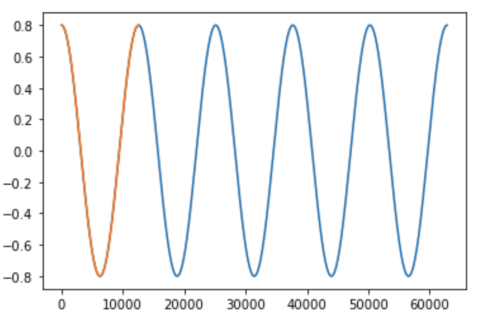

Sonido cosenoidal: $$y = a*cos(bx + c) + d$$

Función de error (LSE): $$e(x) = (y - y_h)^2$$

Ahora con la función de error tenemos que derivar a,b,c y d (Calcula el gradiente que son las derivadas parciales con respecto a a,b,c) y aplicar el algoritmo de gradiente descendiente (Considerando que el gradiente funciona solo con funciones convexas vamos a tomar la parte de la señal convexa, para encontrar los parámetros).

2025-06-06 15:03:55.513176: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-06 15:03:55.520751: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-06 15:03:55.542080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749240235.580848    9257 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749240235.590214    9257 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749240235.622105    9257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

<Axes: >

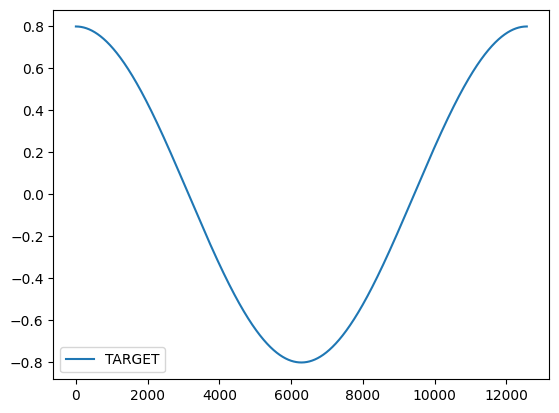

In [1]:
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import write
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Bidirectional, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tr = pd.read_csv("data/grd/train.csv")
ts = pd.read_csv("data/grd/test.csv")

tr.plot(y="TARGET")

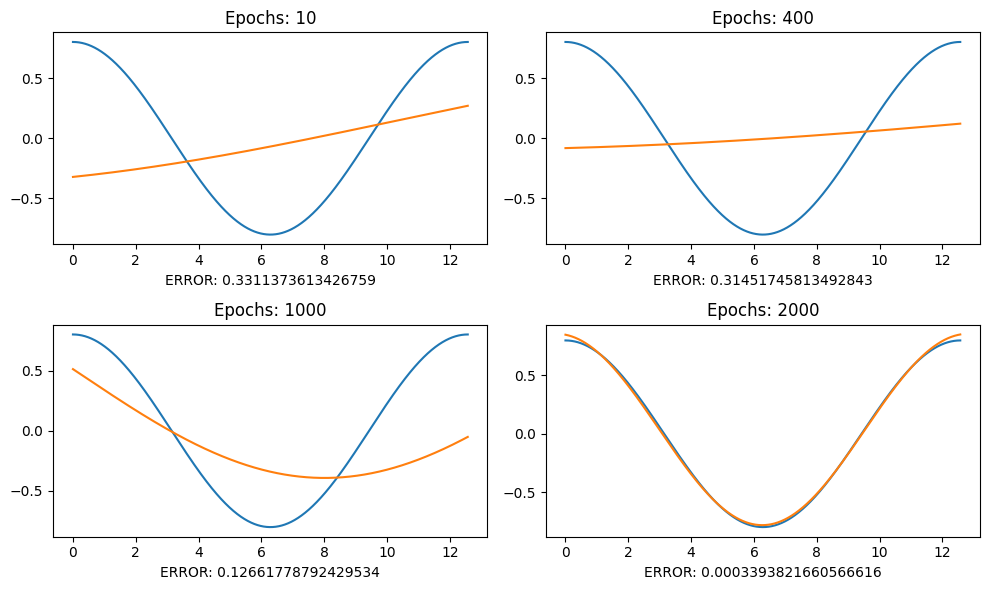

In [2]:
# Gradiente descendiente

x = tr['x'].values
y = tr['TARGET'].values

def get_pred(a,b,c,d,x):
    return (a * np.cos(b*x + c)) + d

def get_err(a,b,c,d,i):
    return (y[i] - get_pred(a,b,c,d,x[i])) ** 2

lr = 0.05
def gradient_descent(lr, epochs, batch):
    np.random.seed(75)
    a, b, c, d, err = np.random.randn(), np.random.randn(), np.random.randn(), 0, 0

    for ep in range(epochs):
        ga, gb, gc, gd = 0, 0, 0, 0

        indices = np.random.choice(len(x), size=batch, replace=False)
        for i in indices:
            err += get_err(a,b,c,d,i)
            r = (y[i] - get_pred(a,b,c,d,x[i]))

            ga += -2 * r * np.cos(b*x[i] + c)
            gb += 2 * r * a * x[i] * np.sin(b*x[i] + c)
            gc += 2 * r * a * np.sin(b*x[i] + c)
            gd += -2 * r

        a -= lr * ga/batch
        b -= lr * gb/batch
        c -= lr * gc/batch
        d -= lr * gd/batch
        err /= batch

    return a,b,c,d,err

plt.figure(figsize=(10, 6))
epochs = [10,400,1000,2000]

for i, ep in enumerate(epochs):
    plt.subplot(2,2,i+1)
    a,b,c,d,err = gradient_descent(lr, ep, 100)
    plt.plot(tr['x'], tr['TARGET'])
    plt.plot(tr['x'], get_pred(a,b,c,d,tr['x']))
    plt.title(f"Epochs: {ep}")
    plt.xlabel(f"ERROR: {err}")

plt.tight_layout()
plt.show()

In [3]:
a,b,c,d,err = gradient_descent(lr, 10000, 100)

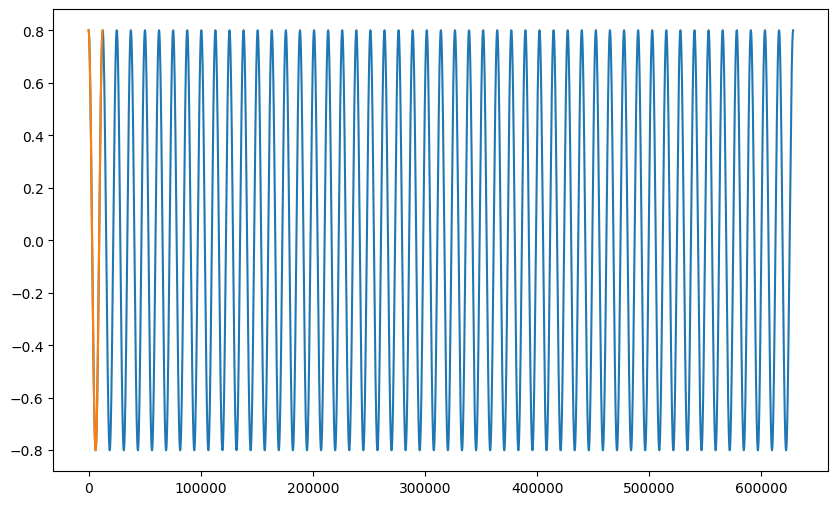

In [4]:
long_s = [get_pred(a,b,c,d,x) for x in np.arange(np.min(x),200*math.pi,0.001).astype(np.float32)]

plt.figure(figsize=(10, 6))
plt.plot(long_s)
plt.plot(y)
plt.show()

sd.play(long_s)

write('output/audio.wav', 44100, np.array(long_s).astype(np.float32))

In [5]:
output = pd.DataFrame({
    "example_id": ts['example_id'],
    "TARGET": get_pred(a,b,c,d,ts['x'])
})

output.to_csv("output/wave.csv", index=False)

## 2. Clasificador

Vamos a hacer un clasificador del tipo de contenido basados en el titulo.

Utilizar todos los datos, y explorar el numero total de palabras únicas en todos los títulos de train y el numero total de repeticiones (Crear un diccionario para saber si la palabra ya fue observada antes e intentar remover tildes y poner el texto en minúsculas), ¿Cuántas palabras hay en el data set.

In [6]:
tr = pd.read_csv("data/cls/train.csv")

dictionary = []

def fix_title(title):
    return re.sub(r'[/\-,.:;#+*$%&()<>_{}\[\]!?\\]+','',title.lower()).replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")

for title in tr["titulo"]:
    fixed_title = fix_title(title)
    words = [word for word in re.split(r'[^a-zA-Zñü]+', fixed_title) if word]

    for word in words:
        if word not in dictionary:
            dictionary.append(word)

In [7]:
dataset = []

for title in tr["titulo"]:
    word_counts = Counter(fix_title(title).lower().split())
    row = {}
    for word in dictionary:
        row[word] = word_counts.get(word, 0)
    dataset.append(row)

word_matrix = pd.DataFrame(dataset, index=tr["titulo"])
word_matrix

,de,nada,sirven,los,triunfos,si,la,paz,no,corona,...,magico,puso,opinas,machismo,cortaron,servicios,tranquilo,levantamiento,pesas,competencias
titulo,,,,,,,,,,,,,,,,,,,,,
"""De nada sirven los triunfos si la paz no los corona"" #LaPazHabla",0,1,1,2,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
"""Hay mejores formas para uno mostrar su forma de pensar"" Sofía",1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
#LosNacionalesXSeñal - Bahía Cupica,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
#LosNacionalesXSeñal - Estudiantes Utech balonmano,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
#LosNacionalesXSeñal - Las pruebas de triatlón llenaron de emoción al municipio de Prado,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
¿Qué harías tú? - Esto se puso salsa,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
¿Qué opinas sobre el machismo?,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
¿Te cortarón los servicios?.. Tranquilo ya esta aquí Mr. Trance - Estreno 15 de septiembre,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,0,0


Normalmente las palabras más comunes son llamadas stop words. Y corresponden a los artículos o preposiciones remover las stop words. Y crear una matriz de correlación utilizando dummy variables para las variables objetivo “categoria”. También generar la matrix nueva eliminando los stopwords y dividimos por el numero total de palabras en cada título. Esta matriz se llama TF (Term Frequency).

In [8]:
stop_words = [
    'a', 'aca', 'ahi', 'ajena', 'ajeno', 'ajenas', 'ajenos', 'al', 'algo', 'algun',
    'alguna', 'alguno', 'algunos', 'alla', 'alli', 'ambos', 'ante', 'antes', 'aquel',
    'aquella', 'aquello', 'aquellas', 'aquellos', 'aqui', 'arriba', 'asi', 'atras',
    'aun', 'aunque', 'bajo', 'bastante', 'bien', 'cabe', 'cada', 'casi', 'cierta',
    'cierto', 'ciertas', 'ciertos', 'como', 'con', 'conmigo', 'conseguimos',
    'conseguir', 'consigo', 'consigue', 'consiguen', 'consigues', 'contigo',
    'contra', 'cual', 'cuales', 'cualquier', 'cualquiera', 'cualesquiera', 'cuan',
    'cuando', 'cuanto', 'cuanta', 'cuantos', 'cuantas', 'de', 'dejar', 'del', 'demas',
    'demasiada', 'demasiado', 'demasiadas', 'demasiados', 'dentro', 'desde', 'donde',
    'dos', 'el', 'el', 'ella', 'ello', 'ellas', 'ellos', 'empleais', 'emplean',
    'emplear', 'empleas', 'empleo', 'en', 'encima', 'entonces', 'entre', 'era',
    'eras', 'eramos', 'eran', 'eres', 'es', 'esa', 'ese', 'eso', 'esas', 'esos',
    'esta', 'estas', 'estaba', 'estado', 'estais', 'estamos', 'estan', 'estar',
    'este', 'esto', 'estos', 'estoy', 'etc', 'fin', 'fue', 'fueron', 'fui',
    'fuimos', 'gueno', 'ha', 'hace', 'haces', 'haceis', 'hacemos', 'hacen', 'hacer',
    'hacia', 'hago', 'hasta', 'incluso', 'intenta', 'intentas', 'intentais',
    'intentamos', 'intentan', 'intentar', 'intento', 'ir', 'jamas', 'junto',
    'juntos', 'la', 'lo', 'los', 'las', 'largo', 'mas', 'me', 'menos', 'mi', 'mis',
    'mia', 'mias', 'mientras', 'mio', 'mios', 'misma', 'mismo', 'mismas', 'mismos',
    'modo', 'mucha', 'muchas', 'muchisima', 'muchisimo', 'muchisimas',
    'muchisimos', 'mucho', 'muchos', 'muy', 'nada', 'ni', 'ningun', 'ninguna',
    'ninguno', 'ningunos', 'no', 'nos', 'nosotras', 'nosotros', 'nuestra',
    'nuestro', 'nuestras', 'nuestros', 'nunca', 'os', 'otra', 'otro', 'otras',
    'otros', 'para', 'parecer', 'pero', 'poca', 'poco', 'pocas', 'pocos', 'podeis',
    'podemos', 'poder', 'podria', 'podrias', 'podriais', 'podriamos', 'podrian',
    'por', 'por que', 'porque', 'primero', 'puede', 'pueden', 'puedo', 'pues', 'que',
    'que', 'querer', 'quien', 'quienes', 'quienesquiera', 'quienquiera', 'quiza',
    'quizas', 'sabe', 'sabes', 'saben', 'sabeis', 'sabemos', 'saber', 'se', 'segun',
    'ser', 'si', 'si', 'siempre', 'siendo', 'sin', 'sino', 'so', 'sobre', 'sois',
    'solamente', 'solo', 'solo', 'somos', 'soy', 'sr', 'sra', 'sres', 'sta', 'su',
    'sus', 'suya', 'suyo', 'suyas', 'suyos', 'tal', 'tales', 'tambien', 'tampoco',
    'tan', 'tanta', 'tanto', 'tantas', 'tantos', 'te', 'teneis', 'tenemos', 'tener',
    'tengo', 'ti', 'tiempo', 'tiene', 'tienen', 'toda', 'todo', 'todas', 'todos',
    'tomar', 'trabaja', 'trabajo', 'trabajais', 'trabajamos', 'trabajan', 'trabajar',
    'trabajas', 'tras', 'tu', 'tu', 'tus', 'tuya', 'tuyo', 'tuyas', 'tuyos',
    'ultima', 'ultimo', 'un', 'una', 'uno', 'unos', 'usa', 'usas', 'usais', 'usamos',
    'usan', 'usar', 'uso', 'usted', 'ustedes', 'va', 'van', 'vais', 'valor', 'vamos',
    'varias', 'varios', 'vaya', 'verdadera', 'vosotras', 'vosotros', 'voy',
    'vuestra', 'vuestro', 'vuestras', 'vuestros', 'y', 'ya', 'yo', 'a',
    'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'ñ', 'o',
    'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
]

word_matrix = word_matrix.drop(columns=stop_words, errors="ignore")
word_matrix = word_matrix.div(word_matrix.sum(axis=1),axis=0).fillna(0)

In [9]:
dumm_words = pd.get_dummies(word_matrix.assign(category=["Educación y Otros" if cat in ["Educación","Gente y Blogs", "Otros"] else cat for cat in tr["categoria"]]))
dumm_words

,sirven,triunfos,paz,corona,lapazhabla,hay,mejores,formas,mostrar,forma,...,cortaron,servicios,tranquilo,levantamiento,pesas,competencias,category_Deportes,category_Educación y Otros,category_Entretenimiento,category_Película y Animación
titulo,,,,,,,,,,,,,,,,,,,,,
"""De nada sirven los triunfos si la paz no los corona"" #LaPazHabla",0.25,0.25,0.25,0.0,0.25,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,True
"""Hay mejores formas para uno mostrar su forma de pensar"" Sofía",0.00,0.00,0.00,0.0,0.00,0.0,0.2,0.2,0.2,0.2,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,True
#LosNacionalesXSeñal - Bahía Cupica,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False,False,False
#LosNacionalesXSeñal - Estudiantes Utech balonmano,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False,False,False
#LosNacionalesXSeñal - Las pruebas de triatlón llenaron de emoción al municipio de Prado,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
¿Qué harías tú? - Esto se puso salsa,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,False
¿Qué opinas sobre el machismo?,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,True
¿Te cortarón los servicios?.. Tranquilo ya esta aquí Mr. Trance - Estreno 15 de septiembre,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.142857,0.142857,0.142857,0.000000,0.000000,0.000000,False,False,False,True


In [10]:
# Son 4 categorias, aquí solo tomo la correlación entre cada palabra y cada categoría
word_corr = dumm_words.corr().iloc[:, -6:].fillna(0)[:-6]
word_corr

,pesas,competencias,category_Deportes,category_Educación y Otros,category_Entretenimiento,category_Película y Animación
sirven,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
triunfos,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
paz,-0.002137,-0.002137,0.001956,-0.036624,0.012968,0.023295
corona,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
lapazhabla,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
...,...,...,...,...,...,...
machismo,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
cortaron,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
servicios,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350
tranquilo,-0.001252,-0.001252,-0.019676,-0.021447,-0.021993,0.067350


Ahora vamos a crear un vector contando el numero de titulos que tiene cada palabra. Este vector tiene “n” elementos y el valor es el número de títulos que tiene la palabra. Por último vamos a transformar el numero calculando el $$log(Total de documentos/ 
(Numero de documentos con la Palabra i + 1) )$$.

In [11]:
word_count = {}

for word in dictionary:
    if word not in stop_words:
        word_count[word] = 0
        for title in tr["titulo"]:
            if word in fix_title(title):
                word_count[word] += 1

word_count = pd.DataFrame({
    "count": word_count
})

def transform_count(row):
    return np.log((len(word_matrix)+1)/(row+1))

word_count = word_count.apply(transform_count)
word_count

,count
sirven,5.992714
triunfos,5.992714
paz,5.299567
corona,5.992714
lapazhabla,5.992714
...,...
servicios,5.992714
tranquilo,5.587249
levantamiento,5.992714
pesas,5.992714


Ahora vamos a multiplicar el vector TF (La matriz) * IDF (Vector transpuesto), El resultado es una matriz de m títulos por n palabras. Y dividir el dataset en test y train.

In [12]:
x = word_matrix * word_count["count"].T
y = ["Educación y Otros" if cat in ["Educación","Gente y Blogs", "Otros"] else cat for cat in tr["categoria"]]
xr, xs, yr, ys = train_test_split(x, y, random_state=75, test_size=0.2)
x

,sirven,triunfos,paz,corona,lapazhabla,hay,mejores,formas,mostrar,forma,...,magico,puso,opinas,machismo,cortaron,servicios,tranquilo,levantamiento,pesas,competencias
titulo,,,,,,,,,,,,,,,,,,,,,
"""De nada sirven los triunfos si la paz no los corona"" #LaPazHabla",1.498178,1.498178,1.324892,0.0,1.498178,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"""Hay mejores formas para uno mostrar su forma de pensar"" Sofía",0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.198543,1.198543,1.198543,1.059913,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
#LosNacionalesXSeñal - Bahía Cupica,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
#LosNacionalesXSeñal - Estudiantes Utech balonmano,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
#LosNacionalesXSeñal - Las pruebas de triatlón llenaron de emoción al municipio de Prado,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
¿Qué harías tú? - Esto se puso salsa,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,1.997571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
¿Qué opinas sobre el machismo?,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,2.996357,2.996357,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
¿Te cortarón los servicios?.. Tranquilo ya esta aquí Mr. Trance - Estreno 15 de septiembre,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.856102,0.856102,0.798178,0.000000,0.000000,0.000000


Utilizando la matriz vamos a entrenar 3 modelos, una regresión logística, un random forest y una LSTM (utilizando la capa de embedding como la vimos en clase por lo tanto no es necesario el tf idf). Vamos a crear una matriz de confusión y vamos a comparar los 3 modelos. ¿Cuál es el mejor modelo?, incluir métricas como accuracy, precision y recall para cada modelo.

In [13]:
lgr = LogisticRegression(random_state=75)
lgr.fit(xr, yr)

rfo = RandomForestClassifier(random_state=75)
rfo.fit(xr, yr)

titles = [fix_title(t) for t in tr["titulo"]]
tokenizer = Tokenizer(num_words=2048, oov_token="<OOV>")
tokenizer.fit_on_texts(titles)
seq = tokenizer.texts_to_sequences(titles)
pad = pad_sequences(seq, maxlen=32, padding='post')

label_enc = LabelEncoder()
pr, ps, y0, y1 = train_test_split(pad, label_enc.fit_transform(y), random_state=75, test_size=0.2)

halt = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lstm = Sequential()
lstm.add(Embedding(2048, 64))
lstm.add(Bidirectional(LSTM(8)))
lstm.add(Dropout(0.5))
lstm.add(Dense(len(label_enc.classes_), activation='softmax'))
lstm.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])
lstm.fit(pr, y0, epochs=64, batch_size=128, validation_data=(ps, y1), callbacks=[halt])

Epoch 1/64


2025-06-06 15:04:46.201883: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 0.2618 - loss: 1.3854 - val_accuracy: 0.2438 - val_loss: 1.3771
Epoch 2/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3529 - loss: 1.3676 - val_accuracy: 0.3688 - val_loss: 1.3657
Epoch 3/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3828 - loss: 1.3562 - val_accuracy: 0.3750 - val_loss: 1.3542
Epoch 4/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4401 - loss: 1.3364 - val_accuracy: 0.3812 - val_loss: 1.3414
Epoch 5/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4436 - loss: 1.3260 - val_accuracy: 0.4062 - val_loss: 1.3270
Epoch 6/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4574 - loss: 1.3053 - val_accuracy: 0.4250 - val_loss: 1.3117
Epoch 7/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4636 - loss: 1.2869 - val_accuracy: 0.4563 - val_loss: 1.2942
Epoch 8/64
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5102 - loss: 1.2617 - val_accuracy: 0.5000 - val_loss: 1.2743
Epoch 9/64

Regresión logística
ACC: 0.7125
PRE: 0.7163320595874257
REC: 0.7125 

Random forest
ACC: 0.675
PRE: 0.7291412290652894
REC: 0.675 

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 
LSTM
ACC: 0.6875
PRE: 0.7020499037227215
REC: 0.6875 



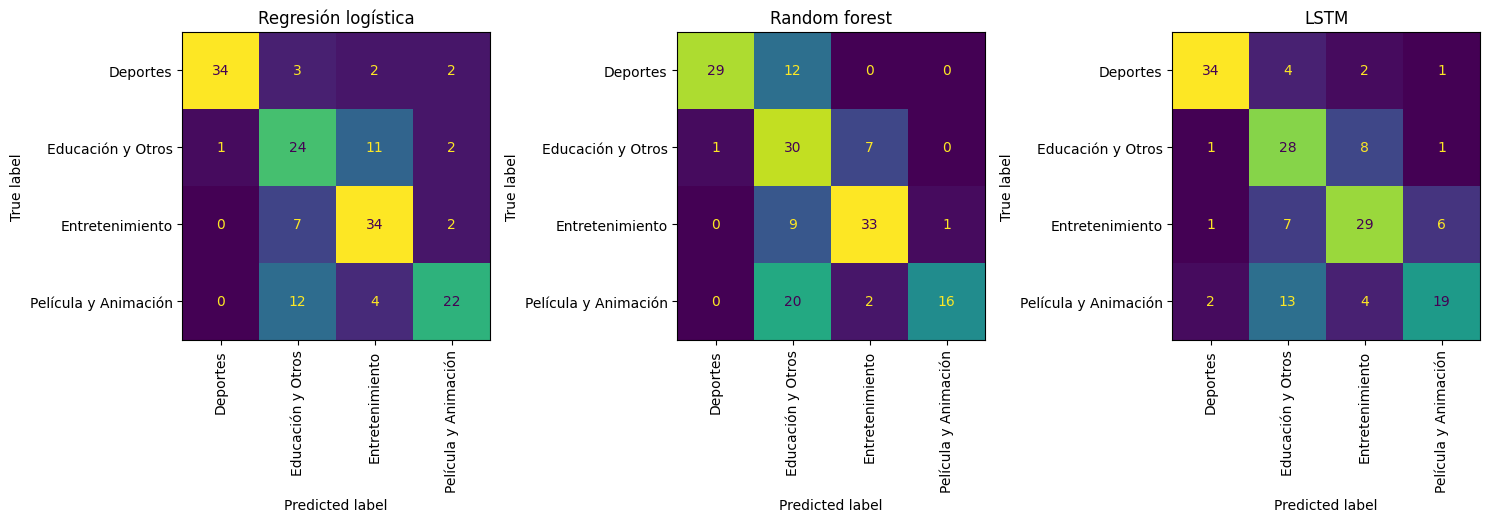

In [14]:
plt.figure(figsize=(15,6))
ys_hat_lgr = lgr.predict(xs)

print("Regresión logística")
print("ACC:", accuracy_score(ys_hat_lgr, ys))
print("PRE:", precision_score(ys_hat_lgr, ys, average="weighted"))
print("REC:", recall_score(ys_hat_lgr, ys, average="weighted"), "\n")

cfm_lgr = confusion_matrix(ys, ys_hat_lgr)
ax = plt.subplot(1,3,1)
disp = ConfusionMatrixDisplay(confusion_matrix=cfm_lgr, display_labels=label_enc.classes_)
disp.plot(ax=ax, colorbar=False)
plt.title("Regresión logística")
plt.xticks(rotation=90)

ys_hat_rfo = rfo.predict(xs)

print("Random forest")
print("ACC:", accuracy_score(ys_hat_rfo, ys))
print("PRE:", precision_score(ys_hat_rfo, ys, average="weighted"))
print("REC:", recall_score(ys_hat_rfo, ys, average="weighted"), "\n")

cfm_rfo = confusion_matrix(ys, ys_hat_rfo)
ax = plt.subplot(1,3,2)
disp = ConfusionMatrixDisplay(confusion_matrix=cfm_rfo, display_labels=label_enc.classes_)
disp.plot(ax=ax, colorbar=False)
plt.title("Random forest")
plt.xticks(rotation=90)

ys_hat_lstm = label_enc.inverse_transform(np.argmax(lstm.predict(ps), axis=1))

print("LSTM")
print("ACC:", accuracy_score(ys_hat_lstm, ys))
print("PRE:", precision_score(ys_hat_lstm, ys, average="weighted"))
print("REC:", recall_score(ys_hat_lstm, ys, average="weighted", zero_division=True), "\n")

cfm_lstm = confusion_matrix(ys, ys_hat_lstm)
ax = plt.subplot(1,3,3)
disp = ConfusionMatrixDisplay(confusion_matrix=cfm_lstm, display_labels=label_enc.classes_)
disp.plot(ax=ax, colorbar=False)
plt.title("LSTM")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [15]:
ts = pd.read_csv("data/cls/test.csv")

dataset = []

for title in ts["titulo"]:
    word_counts = Counter(fix_title(title).lower().split())
    row = {}
    for word in dictionary:
        row[word] = word_counts.get(word, 0)
    dataset.append(row)

test_matrix = pd.DataFrame(dataset, index=ts["titulo"])
test_matrix = test_matrix.drop(columns=stop_words, errors="ignore")
test_matrix = test_matrix.div(test_matrix.sum(axis=1),axis=0).fillna(0)

test_count = {}

for word in dictionary:
    if word not in stop_words:
        test_count[word] = 0
        for title in ts["titulo"]:
            if word in fix_title(title):
                test_count[word] += 1

test_count = pd.DataFrame({"count": test_count})

def transform_count_test(row):
    return np.log((len(test_matrix)+1)/(row+1))

test_count = test_count.apply(transform_count_test)
tf_idf = test_matrix * test_count["count"].T

output_lgr = lgr.predict(tf_idf)
output_lgr = pd.DataFrame({
    "ID": ts["index"],
    "categoria": output_lgr
})
output_lgr.to_csv("output/lgr.csv", index=False)

output_rfo = lgr.predict(tf_idf)
output_rfo = pd.DataFrame({
    "ID": ts["index"],
    "categoria": output_rfo
})
output_rfo.to_csv("output/rfo.csv", index=False)

titles = [fix_title(t) for t in ts["titulo"]]
seq = tokenizer.texts_to_sequences(titles)
pad = pad_sequences(seq, maxlen=20, padding='post', truncating='post')

output_lstm = np.argmax(lstm.predict(pad), axis=1)
output_lstm = pd.DataFrame({
    "ID": ts["index"],
    "categoria": label_enc.inverse_transform(output_lstm)
})
output_lstm.to_csv("output/lstm.csv", index=False)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
